# PROJET FIL ROUGE
##### Modèle de Machine Learning sur les Jeux Olympiques de 2028 à Los Angeles 

---

### **NETTOYAGE ET PRÉPARATION DES DONNÉES**

##### IMPORT DE L'ENVIRONNEMENT DE TRAVAIL

In [1]:
import pandas as pd

df = pd.read_csv("olympics_dataset.csv")

##### VISUALISATION DES DONNÉES

In [2]:
df.head()

,player_id,Name,Sex,Team,NOC,Year,Season,City,Sport,Event,Medal
0,0,A Dijiang,M,China,CHN,1992,Summer,Barcelona,Basketball,Basketball Men's Basketball,No medal
1,1,A Lamusi,M,China,CHN,2012,Summer,London,Judo,Judo Men's Extra-Lightweight,No medal
2,2,Gunnar Aaby,M,Denmark,DEN,1920,Summer,Antwerpen,Football,Football Men's Football,No medal
3,3,Edgar Aabye,M,Denmark/Sweden,DEN,1900,Summer,Paris,Tug-Of-War,Tug-Of-War Men's Tug-Of-War,Gold
4,26,Cornelia (-strannood),F,Netherlands,NED,1932,Summer,Los Angeles,Athletics,Athletics Women's 100 metres,No medal


In [234]:
df.shape

(252565, 11)

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 252565 entries, 0 to 252564
Data columns (total 11 columns):
 #   Column     Non-Null Count   Dtype 
---  ------     --------------   ----- 
 0   player_id  252565 non-null  int64 
 1   Name       252565 non-null  object
 2   Sex        252565 non-null  object
 3   Team       252565 non-null  object
 4   NOC        252565 non-null  object
 5   Year       252565 non-null  int64 
 6   Season     252565 non-null  object
 7   City       252565 non-null  object
 8   Sport      252565 non-null  object
 9   Event      252565 non-null  object
 10  Medal      252565 non-null  object
dtypes: int64(2), object(9)
memory usage: 21.2+ MB


##### VÉRIFICATION DE LA QUALITÉ DES DONNÉES 

In [4]:
df.isna().sum() # vérification des valeurs nulles dans le dataset 

player_id    0
Name         0
Sex          0
Team         0
NOC          0
Year         0
Season       0
City         0
Sport        0
Event        0
Medal        0
dtype: int64

In [5]:
df.duplicated().sum() # vérification des doublons dans le dataset

0

In [6]:
df['player_id'].nunique()

235903

In [7]:
df['Season'].unique() # vérification des colonnes à potentiellement supprimer 

array(['Summer'], dtype=object)

In [8]:
df = df.drop(['Season'], axis=1) # suppression de la colonne Season car 1 seule valeur unique

In [9]:
df["NOC"].nunique() # vérification de la pertinence de la colonne par rapport à Team


234

In [10]:
df["Team"].nunique() # vérification de la pertinence de la colonne par rapport à NOC

1193

##### VALEURS ABERRANTES 

In [11]:
df.head()

,player_id,Name,Sex,Team,NOC,Year,City,Sport,Event,Medal
0,0,A Dijiang,M,China,CHN,1992,Barcelona,Basketball,Basketball Men's Basketball,No medal
1,1,A Lamusi,M,China,CHN,2012,London,Judo,Judo Men's Extra-Lightweight,No medal
2,2,Gunnar Aaby,M,Denmark,DEN,1920,Antwerpen,Football,Football Men's Football,No medal
3,3,Edgar Aabye,M,Denmark/Sweden,DEN,1900,Paris,Tug-Of-War,Tug-Of-War Men's Tug-Of-War,Gold
4,26,Cornelia (-strannood),F,Netherlands,NED,1932,Los Angeles,Athletics,Athletics Women's 100 metres,No medal


Year    Axes(0.125,0.747241;0.110714x0.132759)
dtype: object

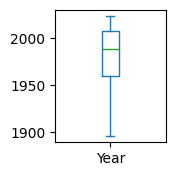

In [12]:
# Visualisation de la seule colonne numérique

df['Year'].plot(
    kind="box",
    subplots=True,
    layout=(5, 6),
    figsize=(10, 10)
)

##### ENCODAGE DES DONNÉES (Sex, Medal)

In [13]:
df['Sex'].unique()

array(['M', 'F'], dtype=object)

In [14]:
df["Sex_encoded"] = df["Sex"].map({"M": 1, "F": 0}) # encodage de Sex pour faciliter la création des champs 

In [15]:
df["Medal"].unique()

array(['No medal', 'Gold', 'Bronze', 'Silver'], dtype=object)

In [16]:
# Normalisation de Medal

df["Medal"] = df["Medal"].str.strip().str.lower()
df["Medal"] = df["Medal"].fillna("no medal")

In [17]:
# Encodage réaliste des médailles

df["Medal_score"] = df["Medal"].map({
    "no medal": 0,
    "bronze": 1,
    "silver": 2,
    "gold": 3
})

In [18]:
df["Medal_score"].value_counts(dropna=False)

Medal_score
0    213747
1     13070
3     13002
2     12746
Name: count, dtype: int64

##### CRÉATION DE NOUVEAUX CHAMPS 

1. FEATURES ATHLÈTES

In [19]:
# Indicateur binaire : l’athlète a-t-il gagné une médaille ?
df["has_medal"] = (df["Medal_score"] > 0).astype(int)

In [20]:
# Durée de carrière olympique (première → dernière participation)

df["histo_athlete_years"] = (
    df.groupby("Name")["Year"]
      .transform(lambda x: x.max() - x.min())
)

In [21]:
# Nombre total de participations par athlète

df["particip_athlete"] = (
    df.groupby("Name")["Year"]
      .transform("count")
)

In [22]:
# Nombre d’équipes distinctes par athlète, pays, année

df["nb_team"] = (
    df.groupby(["Name", "NOC", "Year"])["Team"]
      .transform("nunique")
)

In [23]:
# Score médaille total par athlète

df["medal_score_athlete_total"] = (
    df.groupby("player_id")["Medal_score"]
      .transform("sum")
)

In [24]:
# Nombre total de médailles par athlète

df["nb_medal_athlete"] = (
    df.groupby("player_id")["has_medal"]
      .transform("sum")
)

2. FEATURES PAYS (NOC)

In [25]:
# Nombre total de participations par pays (années distinctes)

df["particip_pays"] = (
    df.groupby("NOC")["Year"]
      .transform("nunique")
)

In [26]:
# Nombre d’athlètes distincts par pays et année

df["nb_athlete_country"] = (
    df.groupby(["NOC", "Year"])["Name"]
      .transform("nunique")
)

In [27]:
# Nombre total de sports distincts par pays

df["nb_sport_country"] = (
    df.groupby("NOC")["Sport"]
      .transform("nunique")
)

In [28]:
# Score médaille total par pays

df["medal_score_country_total"] = (
    df.groupby("NOC")["Medal_score"]
      .transform("sum")
)

In [29]:
# Nombre total de médailles par pays

df["nb_medal_country"] = (
    df.groupby("NOC")["has_medal"]
      .transform("sum")
)

5. PARTIE HÔTE

In [30]:
host_countries = {
    1896: "GRE",
    1900: "FRA",
    1904: "USA",
    1908: "GBR",
    1912: "SWE",
    1920: "BEL",
    1924: "FRA",
    1928: "NED",
    1932: "USA",
    1936: "GER",
    1948: "GBR",
    1952: "FIN",
    1956: "AUS",
    1960: "ITA",
    1964: "JPN",
    1968: "MEX",
    1972: "GER",
    1976: "CAN",
    1980: "URS",
    1984: "USA",
    1988: "KOR",
    1992: "ESP",
    1996: "USA",
    2000: "AUS",
    2004: "GRE",
    2008: "CHN",
    2012: "GBR",
    2016: "BRA",
    2020: "JPN",
    2024: "FRA",
}

In [31]:
host_df = pd.DataFrame.from_dict(
    host_countries,
    orient="index",
    columns=["host_NOC"]
)
host_df.index.name = "Year"

In [32]:
df = df.merge(host_df, on="Year", how="left")

In [33]:
df["is_host_country"] = (df["NOC"] == df["host_NOC"]).astype(int)

In [35]:
df["host_NOC"] = df["host_NOC"].fillna("UNK")

6. FILTRE FINAL : conserver des athlètes potentiellement toujours en activité

In [36]:
from datetime import datetime

In [37]:
current_year = datetime.now().year # définir current_year

In [38]:
# Calculer l’année de première participation de chaque athlète

df["first_year_athlete"] = df.groupby("player_id")["Year"].transform("min")
df["years_since_first"] = current_year - df["first_year_athlete"]

In [39]:
# Créer un champ pour identifier les athlètes encore “récents”, qui ont un nombre d'année jusqu'à aujourd'hui inférieur à 20.

df["recent_athlete"] = (df["years_since_first"] <= 20).astype(int)

##### VÉRIFICATION DES CHAMPS CRÉÉS

In [40]:
print(df.shape)
print(df.columns)

(252565, 28)
Index(['player_id', 'Name', 'Sex', 'Team', 'NOC', 'Year', 'City', 'Sport',
       'Event', 'Medal', 'Sex_encoded', 'Medal_score', 'has_medal',
       'histo_athlete_years', 'particip_athlete', 'nb_team',
       'medal_score_athlete_total', 'nb_medal_athlete', 'particip_pays',
       'nb_athlete_country', 'nb_sport_country', 'medal_score_country_total',
       'nb_medal_country', 'host_NOC', 'is_host_country', 'first_year_athlete',
       'years_since_first', 'recent_athlete'],
      dtype='object')


In [41]:
df.head()

,player_id,Name,Sex,Team,NOC,Year,City,Sport,Event,Medal,...,particip_pays,nb_athlete_country,nb_sport_country,medal_score_country_total,nb_medal_country,host_NOC,is_host_country,first_year_athlete,years_since_first,recent_athlete
0,0,A Dijiang,M,China,CHN,1992,Barcelona,Basketball,Basketball Men's Basketball,no medal,...,15,243,54,2569,1218,ESP,0,1992,34,0
1,1,A Lamusi,M,China,CHN,2012,London,Judo,Judo Men's Extra-Lightweight,no medal,...,15,365,54,2569,1218,GBR,0,2012,14,1
2,2,Gunnar Aaby,M,Denmark,DEN,1920,Antwerpen,Football,Football Men's Football,no medal,...,30,151,38,1331,666,BEL,0,1920,106,0
3,3,Edgar Aabye,M,Denmark/Sweden,DEN,1900,Paris,Tug-Of-War,Tug-Of-War Men's Tug-Of-War,gold,...,30,13,38,1331,666,FRA,0,1900,126,0
4,26,Cornelia (-strannood),F,Netherlands,NED,1932,Los Angeles,Athletics,Athletics Women's 100 metres,no medal,...,29,46,48,2147,1108,USA,0,1932,94,0


In [42]:
df.isna().sum() # vérification des valeurs nulles dans le dataset 

player_id                    0
Name                         0
Sex                          0
Team                         0
NOC                          0
Year                         0
City                         0
Sport                        0
Event                        0
Medal                        0
Sex_encoded                  0
Medal_score                  0
has_medal                    0
histo_athlete_years          0
particip_athlete             0
nb_team                      0
medal_score_athlete_total    0
nb_medal_athlete             0
particip_pays                0
nb_athlete_country           0
nb_sport_country             0
medal_score_country_total    0
nb_medal_country             0
host_NOC                     0
is_host_country              0
first_year_athlete           0
years_since_first            0
recent_athlete               0
dtype: int64

##### VIF : GESTION DES FEATURES REDONDANTES (détecter la multicolinéarité entre les variables quantitatives)

In [43]:
from statsmodels.stats.outliers_influence import variance_inflation_factor as VIF

In [44]:
df.columns

Index(['player_id', 'Name', 'Sex', 'Team', 'NOC', 'Year', 'City', 'Sport',
       'Event', 'Medal', 'Sex_encoded', 'Medal_score', 'has_medal',
       'histo_athlete_years', 'particip_athlete', 'nb_team',
       'medal_score_athlete_total', 'nb_medal_athlete', 'particip_pays',
       'nb_athlete_country', 'nb_sport_country', 'medal_score_country_total',
       'nb_medal_country', 'host_NOC', 'is_host_country', 'first_year_athlete',
       'years_since_first', 'recent_athlete'],
      dtype='object')

In [45]:
# Sélection des colonnes et suppression feature par feature selon les résultats du VIF

cols_vif = [
    'Sex_encoded', 'Medal_score', 'has_medal',
    'histo_athlete_years', 'particip_athlete', 'nb_team',
    'medal_score_athlete_total', 'nb_medal_athlete', 'particip_pays',
    'nb_athlete_country', 'nb_sport_country', 'medal_score_country_total',
    'is_host_country', 'years_since_first', 'recent_athlete']

# Colonnes supprimées : 'first_year_athlete', 'nb_medal_country', 'Year'.

In [46]:
X = df[cols_vif]

In [47]:
# Calcul des VIF  

vif = pd.DataFrame()
vif["feature"] = X.columns
vif["VIF"] = [VIF(X.values, i) for i in range(X.shape[1])]
vif["Precision"] = [1 - 1/VIF(X.values, i) for i in range(X.shape[1])]

vif.sort_values("VIF", ascending=False)


,feature,VIF,Precision
7,nb_medal_athlete,58.578099,0.982929
6,medal_score_athlete_total,57.604637,0.982640
2,has_medal,54.868638,0.981775
1,Medal_score,54.062270,0.981503
10,nb_sport_country,34.527357,0.971037
8,particip_pays,22.878939,0.956292
5,nb_team,15.718895,0.936382
9,nb_athlete_country,9.199936,0.891304
13,years_since_first,6.279105,0.840742
0,Sex_encoded,3.690567,0.729039


In [48]:
df.columns

Index(['player_id', 'Name', 'Sex', 'Team', 'NOC', 'Year', 'City', 'Sport',
       'Event', 'Medal', 'Sex_encoded', 'Medal_score', 'has_medal',
       'histo_athlete_years', 'particip_athlete', 'nb_team',
       'medal_score_athlete_total', 'nb_medal_athlete', 'particip_pays',
       'nb_athlete_country', 'nb_sport_country', 'medal_score_country_total',
       'nb_medal_country', 'host_NOC', 'is_host_country', 'first_year_athlete',
       'years_since_first', 'recent_athlete'],
      dtype='object')

In [64]:
num_cols = [
    'Sex_encoded', 'Medal_score', 'has_medal',
    'histo_athlete_years', 'particip_athlete', 'nb_team',
    'medal_score_athlete_total', 'nb_medal_athlete', 'particip_pays',
    'nb_athlete_country', 'nb_sport_country', 'medal_score_country_total',
    'is_host_country', 'years_since_first', 'recent_athlete']


quali_cols = ['NOC','Sport', 'Medal', 'host_NOC']

context_cols = ['City', 'player_id', 'Name', 'Sex', 'Team', 'Event']

In [65]:
df_clean = df[[
    'NOC', 'Sport', 'Medal', 'host_NOC', 
    'Sex_encoded', 'Medal_score', 'has_medal',
    'histo_athlete_years', 'particip_athlete', 'nb_team',
    'medal_score_athlete_total', 'nb_medal_athlete', 'particip_pays',
    'nb_athlete_country', 'nb_sport_country', 'medal_score_country_total',
    'is_host_country', 'years_since_first', 'recent_athlete'
]]

---

### **ANALYSE UNIVARIÉE : Phase CRISP-DM 2 - Compréhension des Données**


##### IMPORT DE L'ENVIRONNEMENT

In [66]:
import numpy as np  #calculS scientifiqueS
import seaborn as sns #visualiser avec des syntaxes simples
import matplotlib.pyplot as plt #visualiser
import sklearn as skl #Creer des modeles de machine learning (pour ce cours, on verra PCA et KMEANS)
from IPython.display import display, Markdown   #afficher
import scipy
import warnings
warnings.filterwarnings('ignore')

##### PREMIÈRES OBSERVATIONS

In [67]:
# Visualisation statistique du dataset générale

df_clean.describe() 

,Sex_encoded,Medal_score,has_medal,histo_athlete_years,particip_athlete,nb_team,medal_score_athlete_total,nb_medal_athlete,particip_pays,nb_athlete_country,nb_sport_country,medal_score_country_total,is_host_country,years_since_first,recent_athlete
count,252565.000000,252565.000000,252565.000000,252565.000000,252565.000000,252565.000000,252565.000000,252565.000000,252565.000000,252565.000000,252565.000000,252565.000000,252565.000000,252565.000000,252565.000000
mean,0.706923,0.307121,0.153695,4.832261,3.906048,1.012579,0.349348,0.174803,23.287241,213.021852,43.134571,2339.393701,0.072366,46.358371,0.236917
std,0.455174,0.789057,0.360657,9.896300,4.563293,0.137730,0.874135,0.399472,7.754388,161.540441,15.644922,3061.632772,0.259093,32.062278,0.425192
min,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000,1.000000,1.000000,1.000000,0.000000,0.000000,2.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000,18.000000,79.000000,33.000000,359.000000,0.000000,22.000000,0.000000
50%,1.000000,0.000000,0.000000,0.000000,2.000000,1.000000,0.000000,0.000000,25.000000,177.000000,45.000000,1287.000000,0.000000,38.000000,0.000000
75%,1.000000,0.000000,0.000000,8.000000,5.000000,1.000000,0.000000,0.000000,30.000000,309.000000,57.000000,3263.000000,0.000000,66.000000,0.000000
max,1.000000,3.000000,1.000000,120.000000,76.000000,8.000000,13.000000,6.000000,31.000000,732.000000,67.000000,12592.000000,1.000000,130.000000,1.000000


In [68]:
df_clean.shape

(252565, 19)

In [69]:
df_clean.head()

,NOC,Sport,Medal,host_NOC,Sex_encoded,Medal_score,has_medal,histo_athlete_years,particip_athlete,nb_team,medal_score_athlete_total,nb_medal_athlete,particip_pays,nb_athlete_country,nb_sport_country,medal_score_country_total,is_host_country,years_since_first,recent_athlete
0,CHN,Basketball,no medal,ESP,1,0,0,0,1,1,0,0,15,243,54,2569,0,34,0
1,CHN,Judo,no medal,GBR,1,0,0,0,1,1,0,0,15,365,54,2569,0,14,1
2,DEN,Football,no medal,BEL,1,0,0,0,1,1,0,0,30,151,38,1331,0,106,0
3,DEN,Tug-Of-War,gold,FRA,1,3,1,0,1,1,3,1,30,13,38,1331,0,126,0
4,NED,Athletics,no medal,USA,0,0,0,0,2,1,0,0,29,46,48,2147,0,94,0


##### DISTRIBUTION VARIABLES QUALITATIVES

In [ ]:
num_cols = [
    'Sex_encoded', 'Medal_score', 'has_medal',
    'histo_athlete_years', 'particip_athlete', 'nb_team',
    'medal_score_athlete_total', 'nb_medal_athlete', 'particip_pays',
    'nb_athlete_country', 'nb_sport_country', 'medal_score_country_total',
    'is_host_country', 'years_since_first', 'recent_athlete']


quali_cols = ['NOC','Sport', 'Medal', 'host_NOC']

host_NOC
USA    27504
JPN    22823
GBR    22426
FRA    22061
AUS    18948
GER    16810
GRE    13823
BRA    13688
CHN    13602
ESP    12977
KOR    12037
CAN     8641
MEX     8588
FIN     8270
ITA     8119
URS     7191
NED     4992
BEL     4292
SWE     4040
UNK     1733
Name: count, dtype: int64


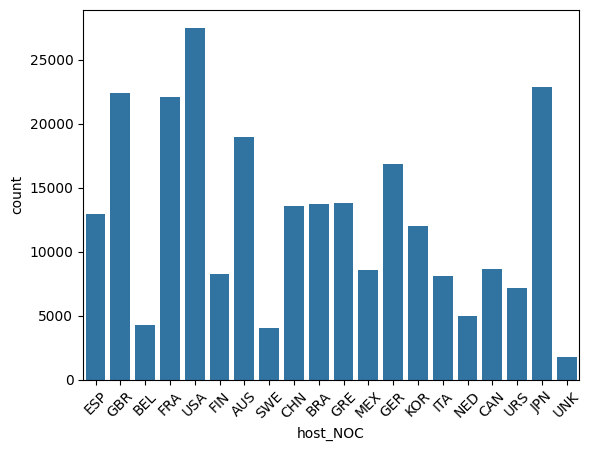

Medal
no medal    213747
bronze       13070
gold         13002
silver       12746
Name: count, dtype: int64


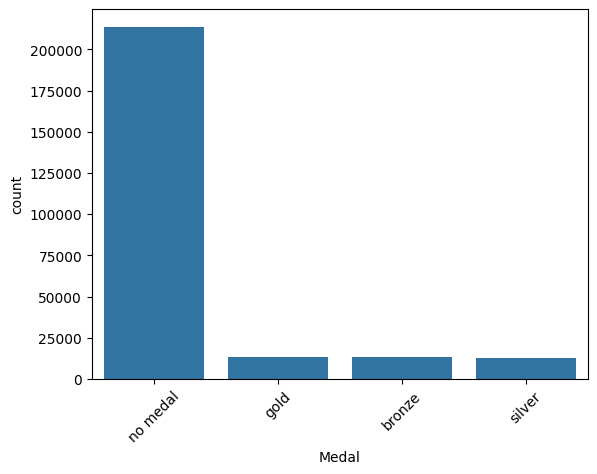

In [ ]:

quali_cols = df[['host_NOC', 'Medal']].columns

for col in quali_cols:
    print(df[col].value_counts())
    sns.countplot(data=df, x=col)
    plt.xticks(rotation=45)
    plt.show()


<Axes: ylabel='count'>

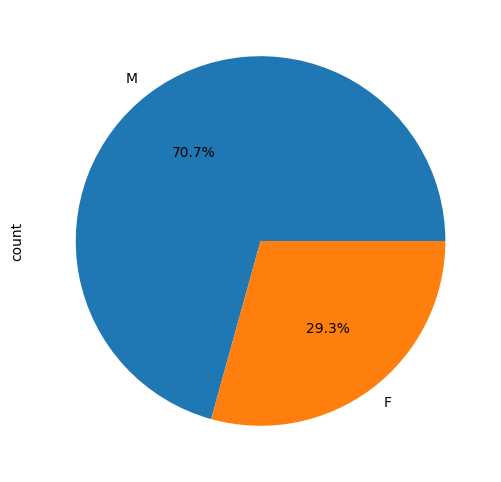

In [ ]:
df.Sex.value_counts().plot(kind="pie",figsize=(6,6), autopct='%1.1f%%')

##### DISTRIBUTION VARIABLES NUMÉRIQUES 

has_medal
0    213747
1     38818
Name: count, dtype: int64


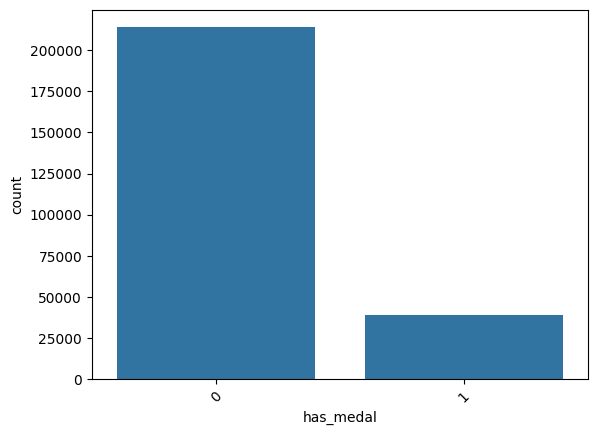

Sex_encoded
1    178544
0     74021
Name: count, dtype: int64


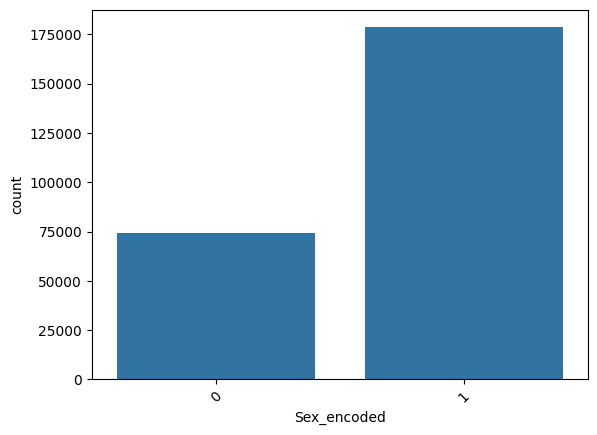

Medal_score
0    213747
1     13070
3     13002
2     12746
Name: count, dtype: int64


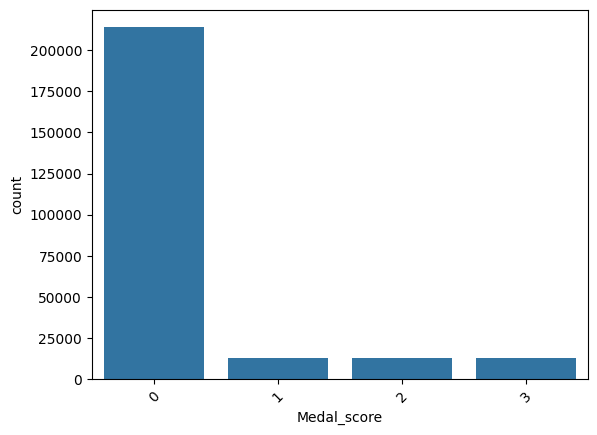

histo_athlete_years
0      126695
4       61508
8       31745
12      14463
16       6080
20       2578
24       1507
28       1173
32        647
36        627
40        497
44        487
6         438
2         421
56        378
64        371
60        334
48        329
68        285
52        282
104       183
76        141
72        137
14        127
18        126
88        123
92        101
100        97
80         95
96         93
84         93
112        83
10         56
22         54
108        37
66         30
116        22
106        20
120        18
26         17
46         15
90         13
30         10
58          9
86          8
50          7
102         3
42          2
Name: count, dtype: int64


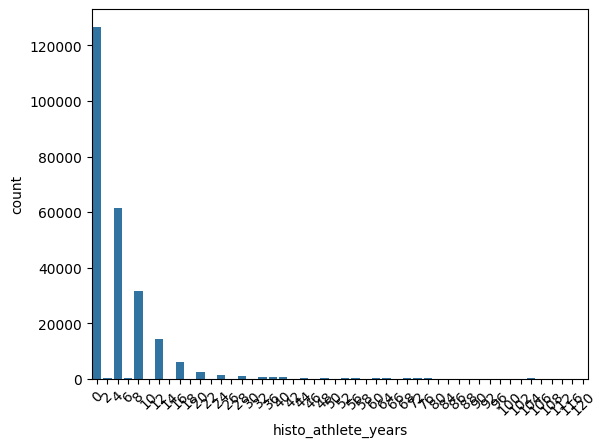

particip_athlete
1     76221
2     59068
3     30918
4     21336
5     13015
6     12384
8      9528
7      6958
16     3792
9      3348
10     2590
12     2280
11     1859
15     1440
13     1274
24     1200
14     1162
17      748
18      486
21      462
23      414
19      342
20      300
22      220
31      155
30      150
32      128
27      108
25      100
26       78
76       76
36       72
29       58
58       58
50       50
49       49
39       39
38       38
33       33
28       28
Name: count, dtype: int64


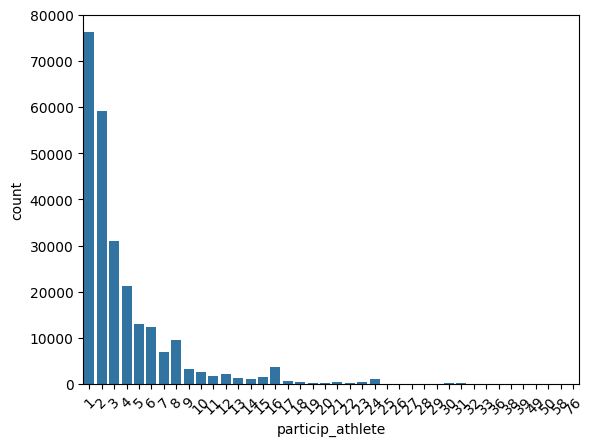

nb_team
1    249792
2      2548
3       158
5        24
8        22
4        21
Name: count, dtype: int64


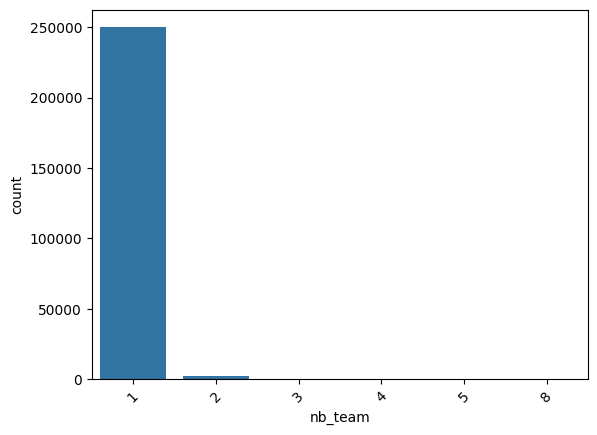

medal_score_athlete_total
0     209871
1      14065
3      14045
2      13798
5        289
4        222
6        144
10        28
8         24
7         24
9         19
11        14
13        11
12        11
Name: count, dtype: int64


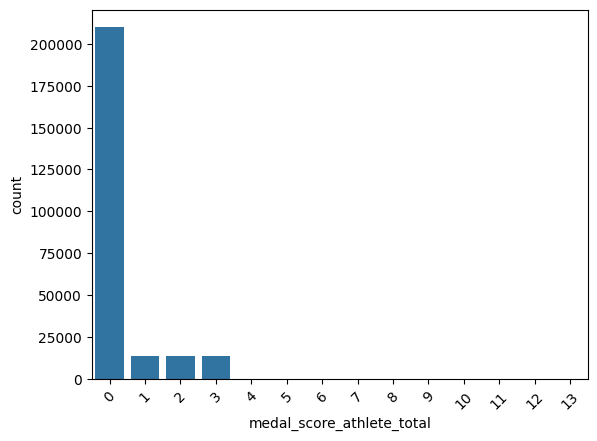

is_host_country
0    234288
1     18277
Name: count, dtype: int64


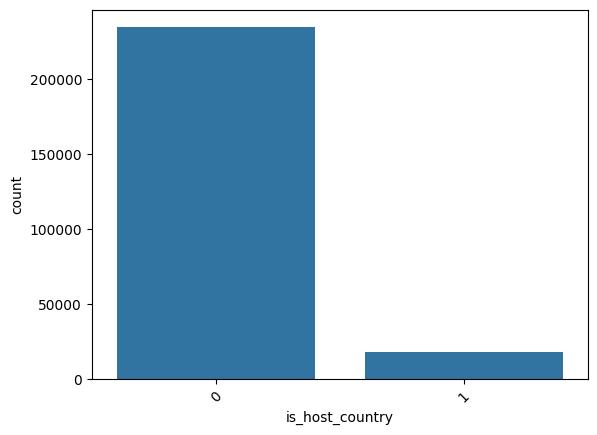

medal_score_athlete_total
0     209871
1      14065
3      14045
2      13798
5        289
4        222
6        144
10        28
8         24
7         24
9         19
11        14
13        11
12        11
Name: count, dtype: int64


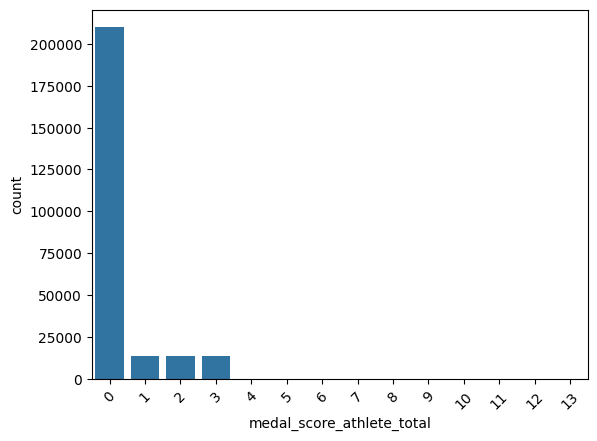

nb_medal_athlete
0    209871
1     41549
2       961
3        97
4        54
5        27
6         6
Name: count, dtype: int64


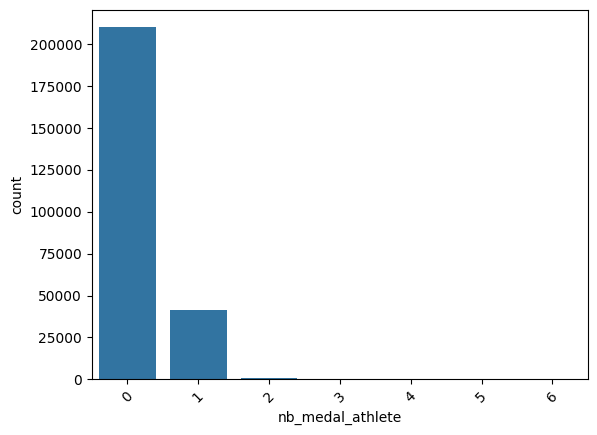

recent_athlete
0    192728
1     59837
Name: count, dtype: int64


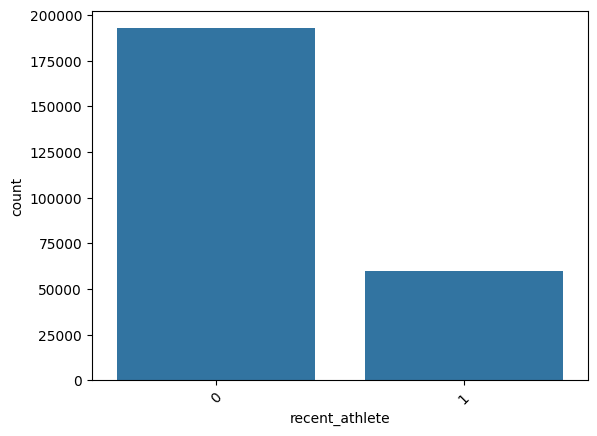

In [ ]:
num_cols = df[['has_medal', 'Sex_encoded', 'Medal_score', 'histo_athlete_years', 'particip_athlete', 'nb_team', 'medal_score_athlete_total', 'is_host_country', 'medal_score_athlete_total', 'nb_medal_athlete', 'recent_athlete' ]].columns

for col in num_cols:
    print(df[col].value_counts())
    sns.countplot(data=df, x=col)
    plt.xticks(rotation=45)
    plt.show()

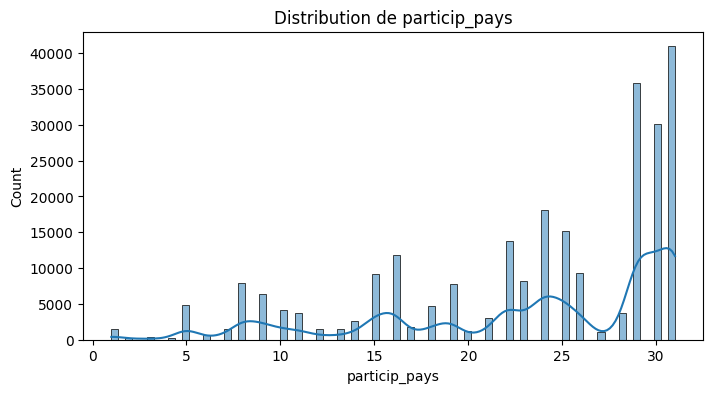

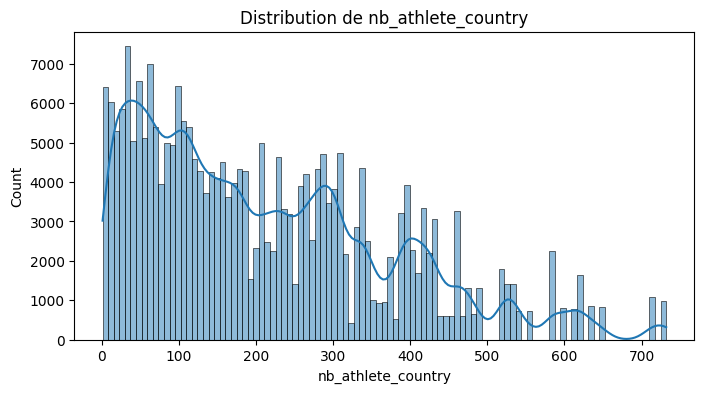

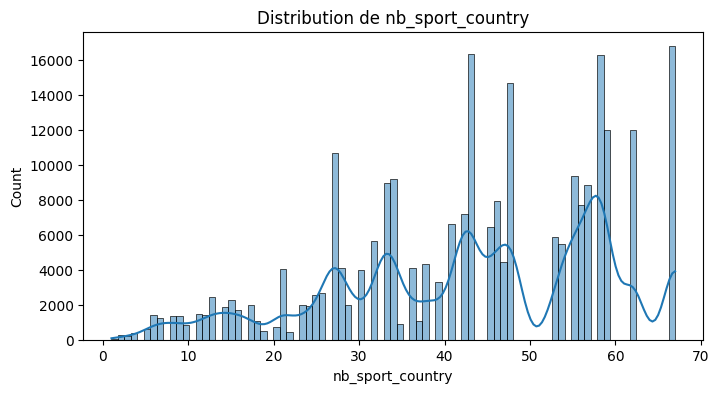

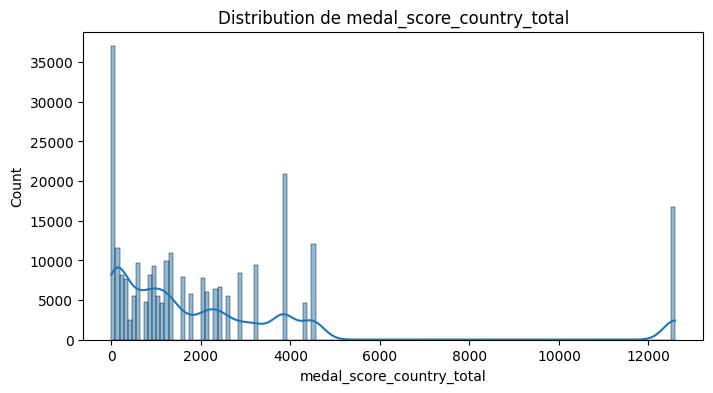

In [ ]:
num_cols = ['particip_pays', 'nb_athlete_country', 'nb_sport_country', 'medal_score_country_total']

for col in num_cols:
    plt.figure(figsize=(8,4))
    sns.histplot(df[col], kde=True)
    plt.title(f"Distribution de {col}")
    plt.show()

---

### **ANALYSE BIVARIÉE**

##### Analyse des variables numériques avec la cible

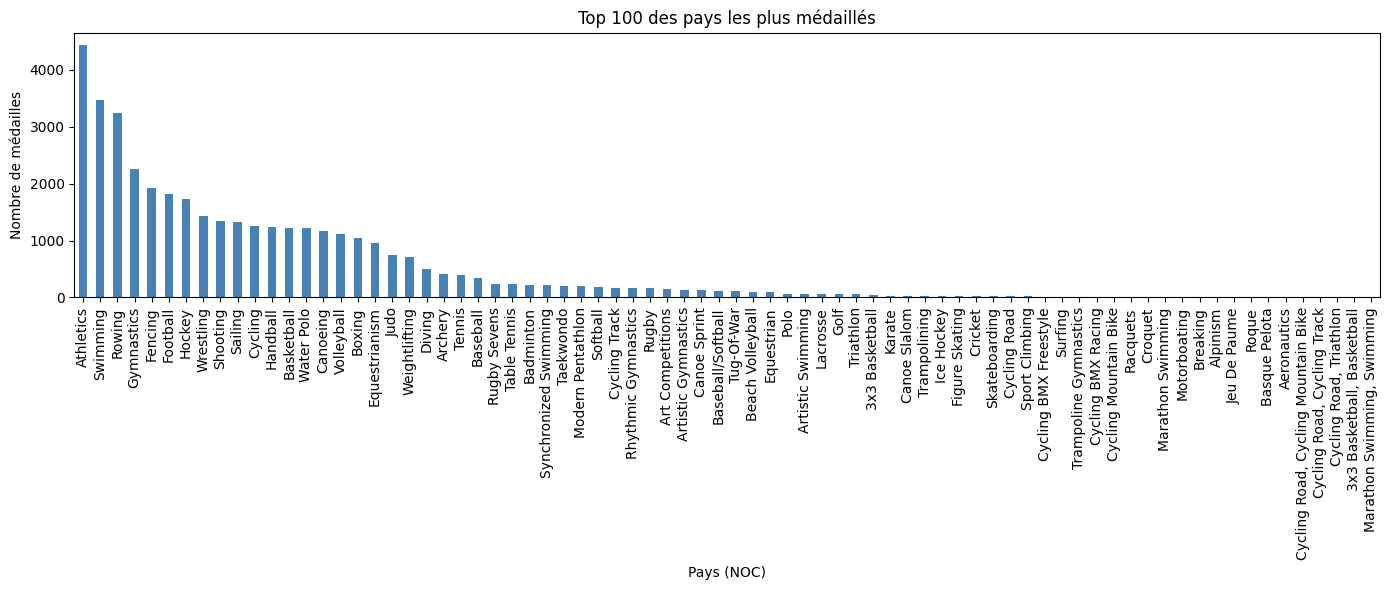

In [ ]:
# distribution globale des médailles par PAYS avec limitation des 100 premiers pays 

medals_by_country = (
    df.groupby("Sport")["has_medal"]
      .sum()
      .sort_values(ascending=False)
      .head(100)  
)

plt.figure(figsize=(14,6))
medals_by_country.plot(kind="bar", color="steelblue")
plt.title("Top 100 des pays les plus médaillés")
plt.xlabel("Pays (NOC)")
plt.ylabel("Nombre de médailles")
plt.tight_layout()
plt.show()

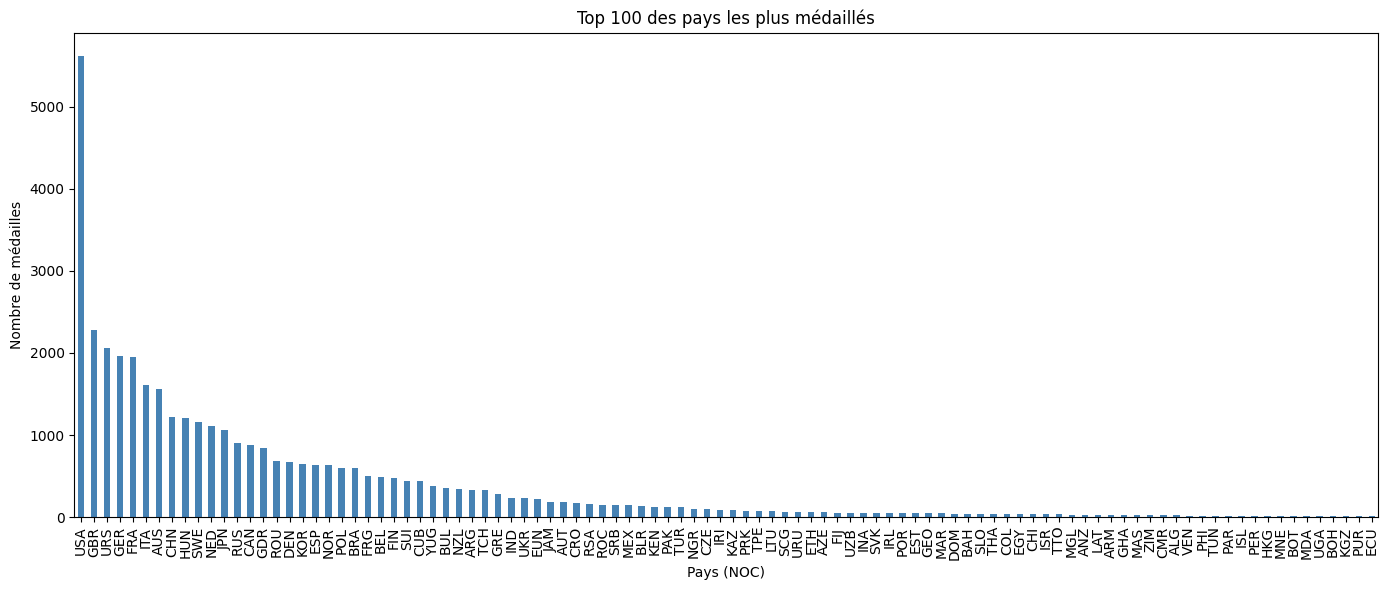

In [ ]:
# distribution globale des médailles par PAYS avec limitation des 100 premiers pays 

medals_by_country = (
    df.groupby("NOC")["has_medal"]
      .sum()
      .sort_values(ascending=False)
      .head(100)  
)

plt.figure(figsize=(14,6))
medals_by_country.plot(kind="bar", color="steelblue")
plt.title("Top 100 des pays les plus médaillés")
plt.xlabel("Pays (NOC)")
plt.ylabel("Nombre de médailles")
plt.tight_layout()
plt.show()


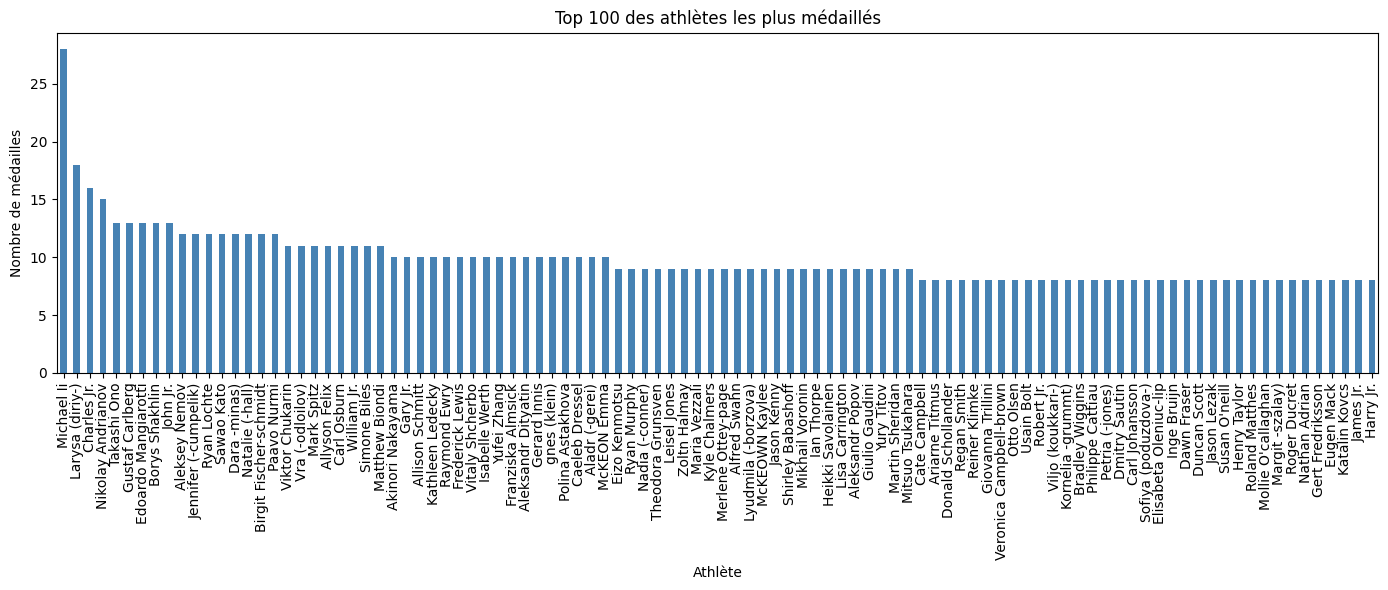

In [ ]:
# distribution globale des médailles par ATHLÈTE avec limitation des 100 premiers athlètes 

medals_by_country = (
    df.groupby("Name")["has_medal"]
      .sum()
      .sort_values(ascending=False)
      .head(100)  
)

plt.figure(figsize=(14,6))
medals_by_country.plot(kind="bar", color="steelblue")
plt.title("Top 100 des athlètes les plus médaillés")
plt.xlabel("Athlète")
plt.ylabel("Nombre de médailles")
plt.tight_layout()
plt.show()

In [ ]:
df.columns

Index(['player_id', 'Name', 'Sex', 'Team', 'NOC', 'Year', 'City', 'Sport',
       'Event', 'Medal', 'Sex_encoded', 'Medal_score', 'has_medal',
       'histo_athlete_years', 'particip_athlete', 'nb_team',
       'medal_score_athlete_total', 'nb_medal_athlete', 'particip_pays',
       'nb_athlete_country', 'nb_sport_country', 'medal_score_country_total',
       'nb_medal_country', 'host_NOC', 'host_city', 'is_host_country',
       'first_year_athlete', 'years_since_first', 'recent_athlete'],
      dtype='object')

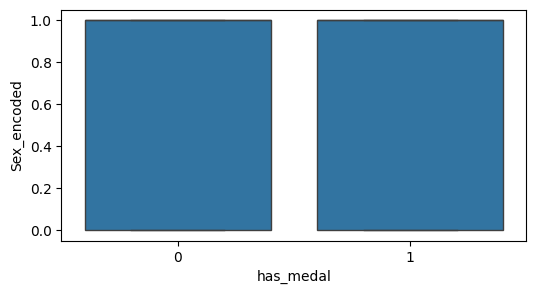

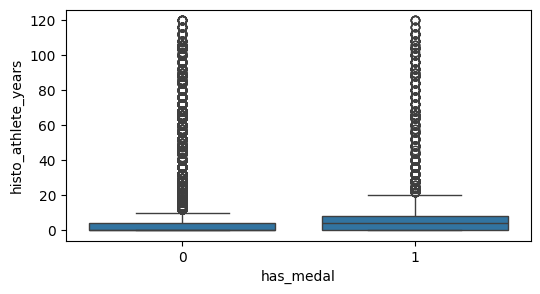

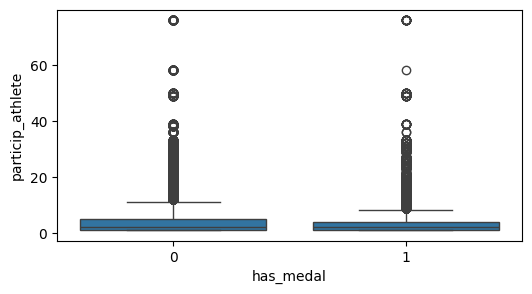

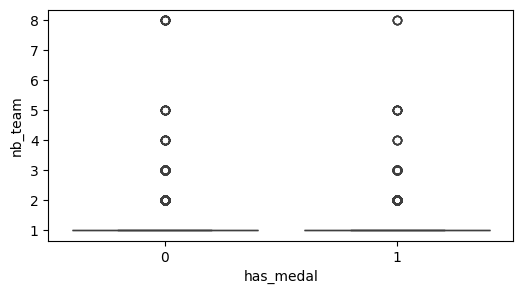

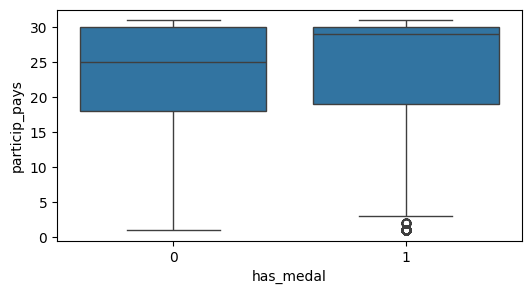

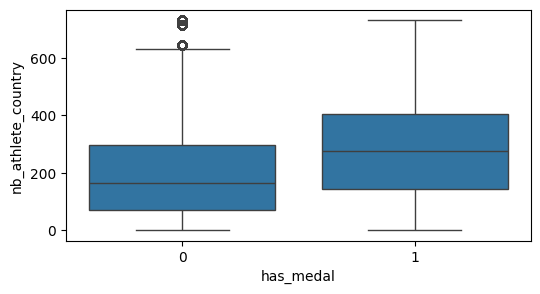

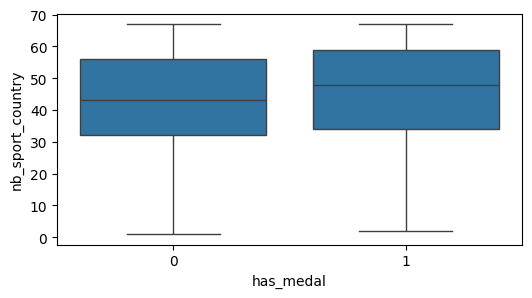

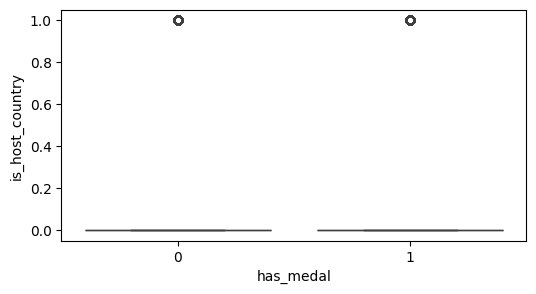

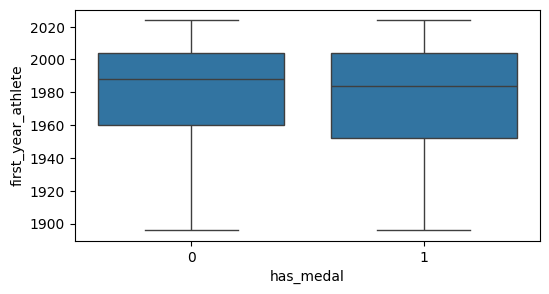

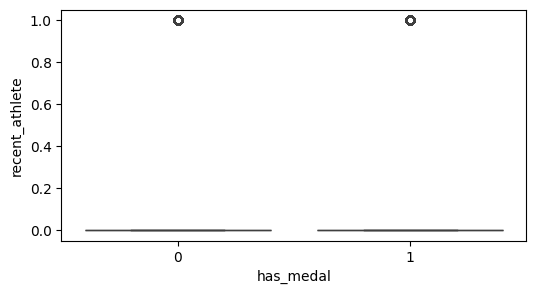

In [ ]:
num_cols = df[['Sex_encoded', 'histo_athlete_years', 'particip_athlete', 'nb_team', 'particip_pays', 'nb_athlete_country', 'nb_sport_country', 'is_host_country', 'first_year_athlete', 'recent_athlete']].columns

for col in num_cols:
    plt.figure(figsize=(6,3))
    sns.boxplot(x="has_medal", y=col, data=df)

##### Correlation entre les variables numériques

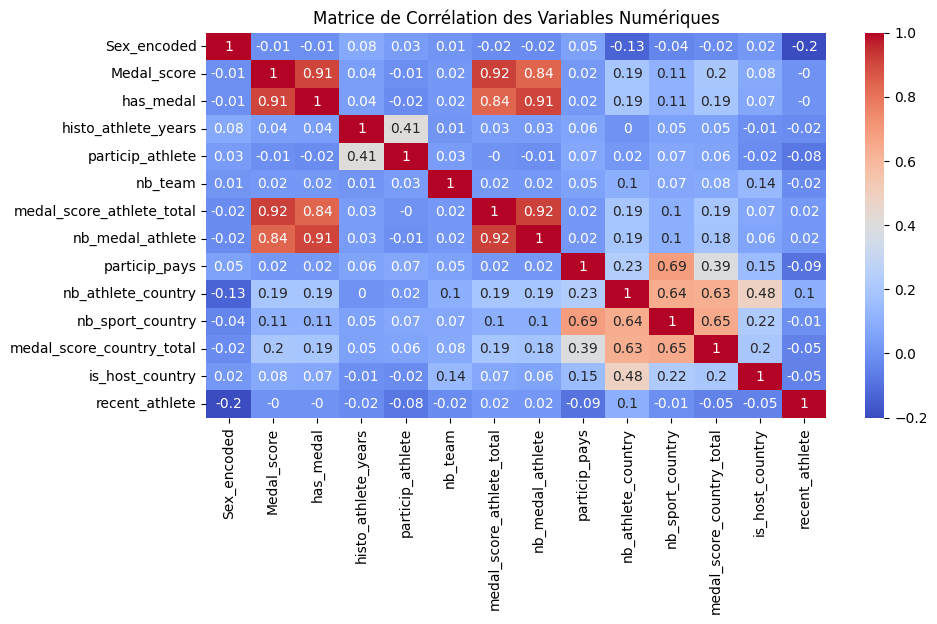

In [ ]:
num_cols = df[
    ['Sex_encoded', 'Medal_score', 'has_medal', 'histo_athlete_years', 'particip_athlete', 
    'nb_team', 'medal_score_athlete_total', 'nb_medal_athlete', 'particip_pays',
    'nb_athlete_country', 'nb_sport_country', 'medal_score_country_total',
    'is_host_country', 'recent_athlete']].columns


plt.figure(figsize=(10, 5))
corr = df[num_cols].corr().round(2)
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Matrice de Corrélation des Variables Numériques")
plt.show()

##### Analyse des variables qualitatives avec la cible 

In [ ]:
df.groupby("Sport")["has_medal"].mean().sort_values(ascending=False)

Sport
Rugby                                  1.0
Cricket                                1.0
Basque Pelota                          1.0
Lacrosse                               1.0
Alpinism                               1.0
                                      ... 
Cycling Road, Cycling Mountain Bike    0.0
Cycling Road, Cycling Track            0.0
Marathon Swimming, Swimming            0.0
Cycling Road, Triathlon                0.0
3x3 Basketball, Basketball             0.0
Name: has_medal, Length: 76, dtype: float64

In [ ]:
df.groupby("NOC")["has_medal"].mean().sort_values(ascending=False)

NOC
URS    0.446344
GDR    0.400665
EUN    0.338462
ANZ    0.337209
USA    0.335102
         ...   
RHO    0.000000
GUM    0.000000
HON    0.000000
PNG    0.000000
LBA    0.000000
Name: has_medal, Length: 234, dtype: float64

In [ ]:
df.groupby("is_host_country")["has_medal"].mean()

is_host_country
0    0.146717
1    0.243147
Name: has_medal, dtype: float64

### **ANALYSE MULTIVARIÉE**

##### Variables numériques

In [ ]:
num_cols = df[
    ['Sex_encoded', 'Medal_score', 'has_medal', 'histo_athlete_years', 'particip_athlete', 
    'nb_team', 'medal_score_athlete_total', 'nb_medal_athlete', 'particip_pays',
    'nb_athlete_country', 'nb_sport_country', 'medal_score_country_total',
    'is_host_country', 'recent_athlete']].columns


In [ ]:
from sklearn.ensemble import RandomForestClassifier

X = df[num_cols].fillna(0)
y = df["has_medal"]

model = RandomForestClassifier()
model.fit(X, y)

importances = pd.Series(model.feature_importances_, index=X.columns)
importances.sort_values(ascending=False).head(15)

has_medal                    0.473519
Medal_score                  0.261640
medal_score_athlete_total    0.131291
nb_medal_athlete             0.124410
medal_score_country_total    0.004323
nb_athlete_country           0.002434
nb_sport_country             0.001477
histo_athlete_years          0.000326
particip_pays                0.000253
is_host_country              0.000117
particip_athlete             0.000108
recent_athlete               0.000069
Sex_encoded                  0.000023
nb_team                      0.000010
dtype: float64

##### Variables qualitatives

In [ ]:
df.columns

Index(['player_id', 'Name', 'Sex', 'Team', 'NOC', 'Year', 'City', 'Sport',
       'Event', 'Medal', 'Sex_encoded', 'Medal_score', 'has_medal',
       'histo_athlete_years', 'particip_athlete', 'nb_team',
       'medal_score_athlete_total', 'nb_medal_athlete', 'particip_pays',
       'nb_athlete_country', 'nb_sport_country', 'medal_score_country_total',
       'nb_medal_country', 'host_NOC', 'host_city', 'is_host_country',
       'first_year_athlete', 'years_since_first', 'recent_athlete'],
      dtype='object')

In [ ]:
quali_cols = ['NOC', 'Sport', 'Team', 'City', 'Event', 'host_NOC', 'host_city']

from scipy.stats import chi2_contingency

for col in quali_cols:
    contingency = pd.crosstab(df[col], df["has_medal"])
    chi2, p, _, _ = chi2_contingency(contingency)
    print(f"{col} : p-value = {p}")

NOC : p-value = 0.0
Sport : p-value = 0.0
Team : p-value = 0.0
City : p-value = 0.0
Event : p-value = 0.0
host_NOC : p-value = 0.0
host_city : p-value = 0.0


##### Interaction entre variables

In [ ]:
df["athlete_strength"] = df["nb_medal_athlete"] * df["particip_athlete"]
df["country_strength"] = df["nb_athlete_country"] * df["nb_sport_country"]

### **CONSTRUCTION DU MODÈLE DE MACHINE LEARNING**

##### Préparation des données

In [ ]:
df["athlete_career_length"] = df.groupby("Name")["Year"].transform(lambda x: x.max() - x.min())

In [ ]:
y = df["has_medal"]

##### Features

In [ ]:
features = [
    # athlete
    "particip_athlete",
    "nb_medal_athlete",
    "nb_team",
    "athlete_strength",
    "athlete_career_length",

    # country
    "nb_athlete_country",
    "nb_sport_country",
    "particip_pays",
    "country_strength",

    # contexte
    "is_host_country",
    "Sex_encoded"
]

##### Dataset final

In [ ]:
X = df[features].fillna(0)

##### TRAIN / TEST SPLIT (TEMPOREL)

In [ ]:
train = df[df["Year"] <= 2016]
test  = df[df["Year"] > 2016]

X_train = train[features].fillna(0)
y_train = train["has_medal"]

X_test = test[features].fillna(0)
y_test = test["has_medal"]

##### GESTION DU DÉSÉQUILIBRE

In [ ]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

weights = compute_class_weight("balanced", classes=np.unique(y_train), y=y_train)
class_weights = {0: weights[0], 1: weights[1]}

##### MODÈLE PRINCIPAL (XGBoost recommandé)

In [ ]:
pip install xgboost

Note: you may need to restart the kernel to use updated packages.


In [ ]:
import xgboost

In [ ]:
from xgboost import XGBClassifier

model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=class_weights[1],
    random_state=42
)

model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.05, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=300,
              n_jobs=None, num_parallel_tree=None, ...)

##### ÉVALUATION

In [ ]:
from sklearn.metrics import classification_report, roc_auc_score

y_proba = model.predict_proba(X_test)[:,1]

threshold = 0.75
y_pred = (y_proba > threshold).astype(int)

print(classification_report(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, y_proba))

              precision    recall  f1-score   support

           0       1.00      0.92      0.96     25283
           1       0.70      0.99      0.82      4730

    accuracy                           0.93     30013
   macro avg       0.85      0.95      0.89     30013
weighted avg       0.95      0.93      0.94     30013

ROC AUC: 0.9679600955241633


##### FEATURE IMPORTANCE

In [ ]:
import pandas as pd

importance = pd.Series(model.feature_importances_, index=features)
importance.sort_values(ascending=False)

nb_medal_athlete         0.821647
athlete_strength         0.173817
nb_sport_country         0.000740
particip_pays            0.000737
nb_athlete_country       0.000665
country_strength         0.000630
athlete_career_length    0.000481
particip_athlete         0.000436
is_host_country          0.000328
Sex_encoded              0.000305
nb_team                  0.000215
dtype: float32

##### PRÉDICTION JO28

In [ ]:
df["medal_proba"] = model.predict_proba(X)[:,1]

##### TOP PAYS 

In [ ]:
country_rank = (
    df_rank.groupby("NOC")["medal_proba"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

country_rank.head(10)

NameError: name 'df_rank' is not defined

##### TOP ATHLÈTES

In [ ]:
df_rank = df.copy()

df_rank["medal_proba"] = model.predict_proba(X)[:,1]

top_athletes = df_rank.sort_values("medal_proba", ascending=False)

top_athletes[["Name", "Sport", "NOC", "medal_proba"]].head(20)

,Name,Sport,NOC,medal_proba
246966,Abbey Weitzeil,Swimming,USA,0.999897
246967,Abbey Weitzeil,Swimming,USA,0.999897
246968,Abbey Weitzeil,Swimming,USA,0.999897
229868,Kathleen Ledecky,Swimming,USA,0.999881
247042,Simone Manuel,Swimming,USA,0.999859
247043,Simone Manuel,Swimming,USA,0.999859
247041,Simone Manuel,Swimming,USA,0.999859
230665,Simone Manuel,Swimming,USA,0.999859
247060,Regan Smith,Swimming,USA,0.999854
247061,Regan Smith,Swimming,USA,0.999854


##### TOP SPORTS

In [ ]:
sport_rank = (
    df_rank.groupby("Sport")["medal_proba"]
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)

sport_rank.head(10)

,Sport,medal_proba
0,Cricket,0.994710
1,Lacrosse,0.993423
2,Rugby,0.989370
3,Alpinism,0.988085
4,Aeronautics,0.988050
5,Basque Pelota,0.979472
6,Racquets,0.826857
7,Roque,0.747911
8,Polo,0.693916
9,Tug-Of-War,0.670034


##### Score composite 

In [ ]:
df_rank["jo_score"] = (
    df_rank["medal_proba"] * 0.7 +
    df_rank["nb_medal_athlete"] * 0.2 +
    df_rank["particip_athlete"] * 0.1
)

---

### **PRÉPARATION DASHBOARD**

In [ ]:
df_dashboard = df[[
    "Name",
    "NOC",
    "Sport",
    "medal_proba"
]]

df_dashboard.to_csv("predictions_JO28.csv", index=False)

##### Feature engineering avancé

In [ ]:
df["athlete_strength"] = df["nb_medal_athlete"] * df["particip_athlete"]
df["country_strength"] = df["nb_athlete_country"] * df["nb_sport_country"]

##### Hyperparameter tuning

In [ ]:
from sklearn.model_selection import GridSearchCV

---

### **CRÉATION ET MISE EN PLACE DU DASHBOARD**

##### CRÉATION

In [ ]:
import streamlit as st
import pandas as pd
import joblib

# ======================
# CONFIG
# ======================
st.set_page_config(page_title="JO28 Dashboard", layout="wide")

st.title("🏅 JO 2028 - Prediction Dashboard")

# ======================
# LOAD DATA + MODEL
# ======================
df = pd.read_csv("predictions_JO28.csv")

# Si tu sauvegardes ton modèle :
# model = joblib.load("model.pkl")

# ======================
# FEATURES (doivent matcher ton modèle)
# ======================
features = [
    "particip_athlete",
    "nb_medal_athlete",
    "nb_team",
    "nb_athlete_country",
    "nb_sport_country",
    "particip_pays",
    "is_host_country",
    "Sex_encoded",
    "athlete_career_length"
]

df["medal_proba"]

# ======================
# SIDEBAR FILTERS
# ======================
st.sidebar.header("🎛️ Filtres")

countries = st.sidebar.multiselect(
    "🌍 Pays",
    df["NOC"].unique()
)

sports = st.sidebar.multiselect(
    "🏅 Sports",
    df["Sport"].unique()
)

threshold = st.sidebar.slider(
    "🎯 Seuil de médaille",
    0.0, 1.0, 0.7, 0.01
)

# ======================
# FILTER DATA
# ======================
filtered_df = df.copy()

if countries:
    filtered_df = filtered_df[filtered_df["NOC"].isin(countries)]

if sports:
    filtered_df = filtered_df[filtered_df["Sport"].isin(sports)]

filtered_df["prediction"] = (filtered_df["medal_proba"] > threshold).astype(int)

# ======================
# KPIs
# ======================
st.subheader("📊 Indicateurs clés")

col1, col2, col3 = st.columns(3)

col1.metric("Athlètes", len(filtered_df))
col2.metric("Médaillés prédits", filtered_df["prediction"].sum())
col3.metric("Proba moyenne", round(filtered_df["medal_proba"].mean(), 3))

# ======================
# TOP ATHLÈTES
# ======================
st.subheader("🥇 Top Athlètes")

top_athletes = filtered_df.sort_values("medal_proba", ascending=False)

st.dataframe(
    top_athletes[["Name", "NOC", "Sport", "medal_proba", "prediction"]].head(20)
)

# ======================
# TOP PAYS
# ======================
st.subheader("🌍 Classement des pays")

country_rank = (
    filtered_df.groupby("NOC")["medal_proba"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

st.bar_chart(country_rank.set_index("NOC"))

# ======================
# TOP SPORTS
# ======================
st.subheader("🏅 Classement des sports")

sport_rank = (
    filtered_df.groupby("Sport")["medal_proba"]
    .mean()
    .sort_values(ascending=False)
)

st.bar_chart(sport_rank)

# ======================
# TABLE DÉTAILLÉE
# ======================
st.subheader("📋 Analyse détaillée")

st.dataframe(
    filtered_df.sort_values("medal_proba", ascending=False)[
        ["Name", "NOC", "Sport", "medal_proba", "prediction"]
    ]
)

DeltaGenerator()

##### LANCEMENT